In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryCrossentropy
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

2026-03-30 08:13:03.004804: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774858383.224177      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774858383.294270      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774858383.827898      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774858383.827933      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774858383.827936      23 computation_placer.cc:177] computation placer alr

In [2]:
base_path = '/kaggle/input/datasets/abhijithc/covid-pneumonia-gray3/covid_pneumonia_gray3'

In [3]:
for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))}")

pneumonia: 463
covid: 524


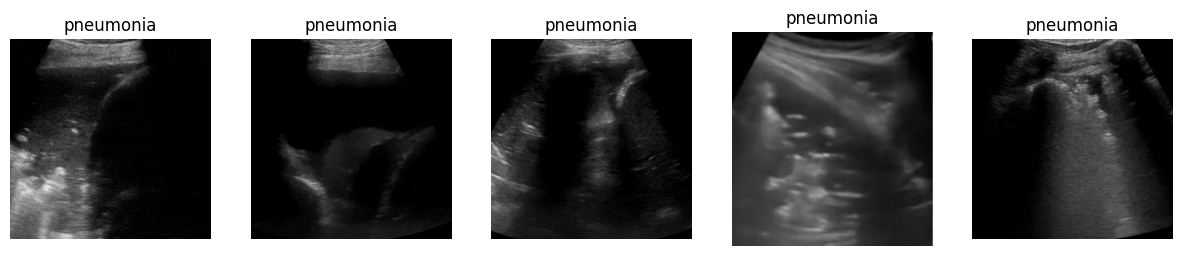

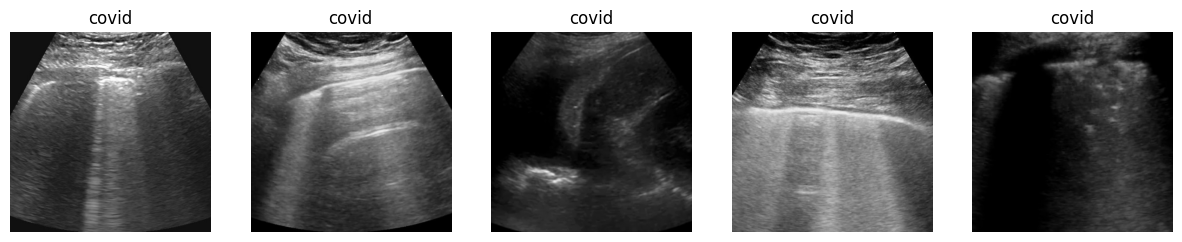

In [4]:
def show_samples(class_path, class_name, n=5):
    images = os.listdir(class_path)
    samples = random.sample(images, min(n, len(images)))

    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(samples):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        show_samples(cls_path, cls)

In [5]:
def get_video_id(path):
    filename = os.path.basename(path)
    filename = filename.split('.')[0]
    filename = filename.replace('-', '_')
    parts = filename.split('_')
    return '_'.join(parts[:2])

In [6]:
image_paths = []
labels = []

for label in os.listdir(base_path):
    class_path = os.path.join(base_path, label)
    for img in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, img))
        labels.append(label)

df = pd.DataFrame({
    "filename": image_paths,
    "label": labels
})

df["video_id"] = df["filename"].apply(get_video_id)

In [7]:
video_df = df[['video_id', 'label']].drop_duplicates().reset_index(drop=True)

# ---------- STEP 3: SEPARATE BY CLASS ----------
covid_videos = video_df[video_df['label'] == 'covid']['video_id'].tolist()
pneumonia_videos = video_df[video_df['label'] == 'pneumonia']['video_id'].tolist()

# ---------- STEP 4: SPLIT FUNCTION ----------
def split_ids(ids, train=0.7, val=0.15, test=0.15):
    train_ids, temp_ids = train_test_split(ids, test_size=(1 - train), random_state=42, shuffle=True)
    val_ratio = val / (val + test)
    val_ids, test_ids = train_test_split(temp_ids, test_size=(1 - val_ratio), random_state=42, shuffle=True)
    return train_ids, val_ids, test_ids

# ---------- STEP 5: SPLIT EACH CLASS ----------
covid_train, covid_val, covid_test = split_ids(covid_videos)
pneu_train, pneu_val, pneu_test = split_ids(pneumonia_videos)

# ---------- STEP 6: MERGE SPLITS ----------
train_ids = set(covid_train + pneu_train)
val_ids   = set(covid_val + pneu_val)
test_ids  = set(covid_test + pneu_test)

# ---------- STEP 7: CREATE FINAL DATAFRAMES ----------
train_df = df[df['video_id'].isin(train_ids)].copy()
val_df   = df[df['video_id'].isin(val_ids)].copy()
test_df  = df[df['video_id'].isin(test_ids)].copy()

# ---------- STEP 8: VERIFY ----------

# No leakage
assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

# Check video-level balance
def check(split_ids, name):
    temp = video_df[video_df['video_id'].isin(split_ids)]
    print(f"\n{name} (video-level)")
    print(temp['label'].value_counts())
    print(temp['label'].value_counts(normalize=True))

check(train_ids, "TRAIN")
check(val_ids, "VAL")
check(test_ids, "TEST")

# Check frame-level distribution
print("\nFrame-level distribution:")
print("TRAIN:\n", train_df['label'].value_counts(normalize=True))
print("VAL:\n", val_df['label'].value_counts(normalize=True))
print("TEST:\n", test_df['label'].value_counts(normalize=True))


TRAIN (video-level)
label
covid        7
pneumonia    6
Name: count, dtype: int64
label
covid        0.538462
pneumonia    0.461538
Name: proportion, dtype: float64

VAL (video-level)
label
pneumonia    2
covid        2
Name: count, dtype: int64
label
pneumonia    0.5
covid        0.5
Name: proportion, dtype: float64

TEST (video-level)
label
pneumonia    2
covid        2
Name: count, dtype: int64
label
pneumonia    0.5
covid        0.5
Name: proportion, dtype: float64

Frame-level distribution:
TRAIN:
 label
covid        0.712551
pneumonia    0.287449
Name: proportion, dtype: float64
VAL:
 label
covid        0.583333
pneumonia    0.416667
Name: proportion, dtype: float64
TEST:
 label
pneumonia    0.669584
covid        0.330416
Name: proportion, dtype: float64


In [8]:
train_df = pd.DataFrame({
    "x": train_df["filename"],
    "y": train_df["label"]
}) 

val_df = pd.DataFrame({
    "x": val_df["filename"],
    "y": val_df["label"]
})

test_df = pd.DataFrame({
    "x": test_df["filename"],
    "y": test_df["label"]
})

In [9]:
train_df['y'].value_counts()
val_df['y'].value_counts()

y
covid        21
pneumonia    15
Name: count, dtype: int64

In [10]:
train_batches = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
    ).flow_from_dataframe(
    dataframe = train_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_batches = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_dataframe(
    dataframe = val_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

test_batches = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_dataframe(
    dataframe = test_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

Found 494 validated image filenames belonging to 2 classes.
Found 36 validated image filenames belonging to 2 classes.
Found 457 validated image filenames belonging to 2 classes.


In [11]:
print(train_batches.class_indices)
print(val_batches.class_indices)
print(test_batches.class_indices)

{'covid': 0, 'pneumonia': 1}
{'covid': 0, 'pneumonia': 1}
{'covid': 0, 'pneumonia': 1}


In [12]:
images, labels = next(train_batches)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..135.13882].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..134.27863].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..106.23348].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..55.72068].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


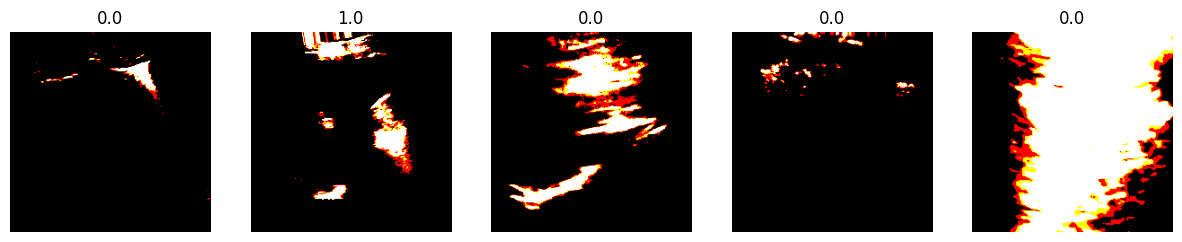

In [13]:
plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.show()

In [14]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

I0000 00:00:1774858411.309835      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774858411.316020      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [15]:
for layer in base_model.layers:
    layer.trainable = False

In [16]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(units=1, activation="sigmoid")
])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [19]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['y']),
    y=train_df['y']
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.7017045454545454), 1: np.float64(1.7394366197183098)}


In [20]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

In [21]:
model.fit(
    x=train_batches,
    validation_data=val_batches,
    epochs=50,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=2
)

Epoch 1/50


I0000 00:00:1774858425.031341      72 service.cc:152] XLA service 0x7fb6d8004f60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774858425.031380      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774858425.031384      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774858426.902182      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774858431.812877      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16/16 - 31s - 2s/step - accuracy: 0.4555 - loss: 1.1738 - val_accuracy: 0.3333 - val_loss: 1.2620
Epoch 2/50
16/16 - 6s - 404ms/step - accuracy: 0.4413 - loss: 1.0843 - val_accuracy: 0.3056 - val_loss: 1.1745
Epoch 3/50
16/16 - 6s - 395ms/step - accuracy: 0.4474 - loss: 1.0320 - val_accuracy: 0.2778 - val_loss: 1.0861
Epoch 4/50
16/16 - 6s - 396ms/step - accuracy: 0.5385 - loss: 0.8521 - val_accuracy: 0.2500 - val_loss: 1.0153
Epoch 5/50
16/16 - 6s - 397ms/step - accuracy: 0.5769 - loss: 0.7592 - val_accuracy: 0.1944 - val_loss: 0.9422
Epoch 6/50
16/16 - 7s - 409ms/step - accuracy: 0.6498 - loss: 0.6433 - val_accuracy: 0.2778 - val_loss: 0.8706
Epoch 7/50
16/16 - 6s - 401ms/step - accuracy: 0.6842 - loss: 0.6090 - val_accuracy: 0.3056 - val_loss: 0.8246
Epoch 8/50
16/16 - 7s - 412ms/step - accuracy: 0.6640 - loss: 0.6357 - val_accuracy: 0.3611 - val_loss: 0.7935
Epoch 9/50
16/16 - 6s - 400ms/step - accuracy: 0.7105 - loss: 0.5764 - val_accuracy: 0.3611 - val_loss: 0.7609
Epoch 10/50
16

15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 540ms/step


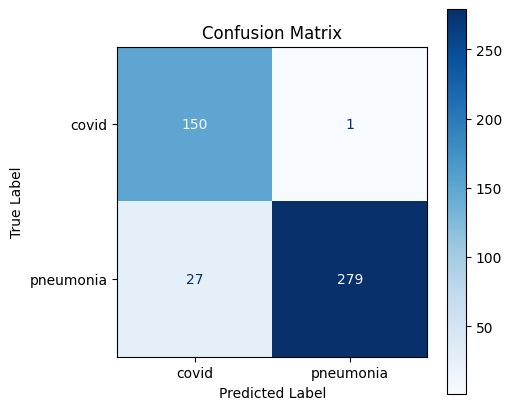

In [22]:
test_batches.reset()

y_pred = model.predict(test_batches)
y_pred = (y_pred > 0.4).astype(int)

cm = confusion_matrix(test_batches.classes, y_pred)

labels = list(test_batches.class_indices.keys())

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [23]:
test_loss, test_acc = model.evaluate(test_batches)
print(test_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.7952 - loss: 0.4429
0.853391706943512


In [24]:
print(classification_report(test_batches.classes, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       151
           1       1.00      0.91      0.95       306

    accuracy                           0.94       457
   macro avg       0.92      0.95      0.93       457
weighted avg       0.95      0.94      0.94       457

